In [1]:
%load_ext autoreload
%autoreload 2

# 511 keV Galactic Imaging

**Objective**

Construct and analyze the extended 511 keV emission image in Galactic coordinates using:

- The binned 511 keV data.
- The precomputed extended-source response.
- The spacecraft attitude history.

This notebook focuses on the spatial distribution of the Galactic disk and bulge.

***
## Setup

In [2]:
# Setting the root path for the imports
from pathlib import Path
import sys

working_dir=Path.cwd()
repo_root = (
    working_dir.parent 
    if working_dir.name =='notebooks' 
    else working_dir
    )
if str(repo_root) not in sys.path: sys.path.insert(0,str(repo_root))

### Imports

In [60]:

import numpy as np
import cosipy as cp
import matplotlib.pyplot as plt


# from cosipy.response import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

# from scoords import SpacecraftFrame

from astropy.io import fits
import astropy.units as u
# from astropy.coordinates import SkyCoord
# from astromodels import Parameter, Powerlaw

import h5py
import healpy as hp


%matplotlib inline

### Paths to input products

In [4]:
# Input products: Adding all paths to be used for this analysis. See `workflor/src/path_to_files.py`
from src import path_to_files as paths
from src.binning_config import write_custom_binning_yaml

In [5]:
# Validate input products
print(paths.data_ext_response511_path)
print(paths.data_ori_path)
print(paths.data_dir_out)

/Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/extended_source_response_511_merged.h5
/Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits
/Users/maura/Documents/COSI/data-challenge-4/workflow/data/outputs


***
## Load 511 keV data

In [6]:
yaml_conf = paths.config_511_path

# Load spacecraft orientation hystory
orientation = cp.SpacecraftHistory.open(paths.data_ori_path)

### Inspect extended-source response

In [7]:
# Load detector response
with h5py.File(paths.data_ext_response511_path, 'r') as response_file:
    extended_response = response_file["hist/contents"][:]
    response_axes = [
        response_file[f"hist/axes/{i}"][:]
        for i in range(5)
    ]

    print(extended_response.shape)
    for i, axis in enumerate(response_axes):
        print(f"Axis {i}: {axis.shape}, first values: {axis[:15]}")

    for i in range(5):
        axis = response_file[f"hist/axes/{i}"]
        print(f"Axis {i}:", dict(axis.attrs))

    print("Contents:", dict(response_file["hist/contents"].attrs))

(3072, 1, 1, 60, 3072)
Axis 0: (3073,), first values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Axis 1: (2,), first values: [509. 513.]
Axis 2: (2,), first values: [509. 513.]
Axis 3: (61,), first values: [ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27. 30. 33. 36. 39. 42.]
Axis 4: (3073,), first values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Axis 0: {'__class__': array(['histpy.healpix_axis', 'HealpixAxis'], dtype=object), 'coordsys': 'galactic', 'label': 'NuLambda', 'nside': np.int64(16), 'scheme': 'RING'}
Axis 1: {'__class__': array(['histpy.axis', 'Axis'], dtype=object), 'label': 'Ei', 'scale': 'log', 'unit': 'keV'}
Axis 2: {'__class__': array(['histpy.axis', 'Axis'], dtype=object), 'label': 'Em', 'scale': 'log', 'unit': 'keV'}
Axis 3: {'__class__': array(['histpy.axis', 'Axis'], dtype=object), 'label': 'Phi', 'scale': 'linear', 'unit': 'deg'}
Axis 4: {'__class__': array(['histpy.healpix_axis', 'HealpixAxis'], dtype=object), 'coordsys': 'galactic', 'label': 'PsiChi', 'nside': 

### Single week

In [8]:
# Single dataset binned. Load one binned dataset as an initial validation before
# processing all weeks.
binned511_w1 = paths.data_dir_out / "dc4_week_1_511_binned.hdf5"

analysis511_week1 = cp.BinnedData(yaml_conf)
analysis511_week1.load_binned_data_from_hdf5(binned_data= binned511_w1)
analysis511_week1.get_binning_info()

In [9]:
print(analysis511_week1.binned_data.shape)
print(len(analysis511_week1.time_bin_centers))

(2217, 1, 60, 3072)
2217


In [10]:
# Convert the sparse observed histogram to a dense array
data_contents = np.asarray(
    analysis511_week1.binned_data.contents.todense()
)

# Sum over time and incident-energy axes
observed_counts = data_contents.sum(axis=(0, 1))


In [11]:
print(observed_counts.shape)
print(observed_counts.sum())

(60, 3072)
119213.0


#### Validate data–response and temporal compatibility

In [12]:
# Observed data: (time, Em, Phi, PsiChi)
print("Data shape:", analysis511_week1.binned_data.shape)

# Extended response: (NuLambda, Ei, Em, Phi, PsiChi)
print("Response shape:", extended_response.shape)

assert analysis511_week1.binned_data.shape[1] == 1
assert analysis511_week1.binned_data.shape[2] == extended_response.shape[3]
assert analysis511_week1.binned_data.shape[3] == extended_response.shape[4]

print("Data and response axes are compatible.")
#print("Total observed counts:", analysis511_week1.binned_data.sum())
print("Response range:", extended_response.min(), extended_response.max())

Data shape: (2217, 1, 60, 3072)
Response shape: (3072, 1, 1, 60, 3072)
Data and response axes are compatible.
Response range: 0.0 13949.2242181167


In [13]:
print("Data time bins:", analysis511_week1.binned_data.shape[0])
print("History intervals:", orientation.nintervals)
print("History points:", orientation.npoints)

print("Orientation time range:")
print(orientation.tstart, orientation.tstop)

print("Orientation intervals:")
print(orientation.intervals_tstart[:3])
print(orientation.intervals_tstop[:3])

print("Orientation livetime shape:", np.shape(orientation.livetime))
print("Orientation attitude shape:", np.shape(orientation.attitude))

Data time bins: 2217
History intervals: 531997
History points: 531998
Orientation time range:
1835487300.0 1843467255.0
Orientation intervals:
[1.83548730e+09 1.83548732e+09 1.83548733e+09]
[1.83548732e+09 1.83548733e+09 1.83548734e+09]
Orientation livetime shape: (531997,)
Orientation attitude shape: (531998,)


In [14]:
print("Data time range:", analysis511_week1.tmin, analysis511_week1.tmax)
print("Data bins:", analysis511_week1.time_bins)
print("Data bin edges:", analysis511_week1.time_bin_edges[:3])
print(analysis511_week1.time_bin_edges[-3:])

print("Orientation range:", orientation.tstart, orientation.tstop)


data_tmin = float(analysis511_week1.tmin)
data_tmax = float(analysis511_week1.tmax)

orientation_tstart = orientation.tstart.unix
orientation_tstop = orientation.tstop.unix

assert data_tmin >= orientation_tstart
assert data_tmax <= orientation_tstop

print("Data:", data_tmin, data_tmax)
print("Orientation:", orientation_tstart, orientation_tstop)


print("Temporal coverage is compatible.")

Data time range: 1835487300.036206 1843467254.887687
Data bins: 3600.0
Data bin edges: [1.8354873e+09 1.8354909e+09 1.8354945e+09] s
[1.84346006e+09 1.84346366e+09 1.84346725e+09] s
Orientation range: 1835487300.0 1843467255.0
Data: 1835487300.036206 1843467254.887687
Orientation: 1835487300.0 1843467255.0
Temporal coverage is compatible.


### All weeks

In [15]:
analysis511 = {}

for week in paths.weekly_paths:
    output_prefix = paths.data_dir_out / f"dc4_week_{week}_511_binned"
    output_path = output_prefix.with_suffix(".hdf5")

    analysis511[week] = cp.BinnedData(yaml_conf)
    analysis511[week].load_binned_data_from_hdf5(
        binned_data = str(output_path)
    )
    analysis511[week].get_binning_info()


In [16]:
print(len(analysis511))
print(analysis511.keys())
for week in range(1,15):
    print(week, analysis511[week].binned_data.shape)

14
dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
1 (2217, 1, 60, 3072)
2 (2217, 1, 60, 3072)
3 (2217, 1, 60, 3072)
4 (2217, 1, 60, 3072)
5 (2217, 1, 60, 3072)
6 (2217, 1, 60, 3072)
7 (2217, 1, 60, 3072)
8 (2217, 1, 60, 3072)
9 (2217, 1, 60, 3072)
10 (2217, 1, 60, 3072)
11 (2217, 1, 60, 3072)
12 (2217, 1, 60, 3072)
13 (2217, 1, 60, 3072)
14 (2217, 1, 60, 3072)


#### Combine weekly counts

In [17]:
observed_counts_all = np.zeros(
    analysis511[1].binned_data.shape[2:],
    dtype=float,
)

for week in range(1, 15):
    week_data = np.asarray(
        analysis511[week].binned_data.contents.todense()
    )

    week_counts = week_data.sum(axis=(0, 1))
    observed_counts_all += week_counts

In [18]:
print(observed_counts_all.shape)
print(observed_counts_all.sum())

(60, 3072)
1576953.0


## 511 keV background estimation

This section follows the COSIpy line-background tutorial. It constructs a data-driven background estimate from measured-energy sidebands, generates several spatially filtered variants, and prepares them for validation against the simulated DC4 total background.


### Tutorial-based data-driven background estimate


The tutorial workflow used here has four stages:

1. Inspect the measured-energy spectrum around 511 keV.
2. Re-bin the weekly events with fine measured-energy bins.
3. Fit a spectral background model outside the source-dominated region.
4. Use energy sidebands to generate spatial background templates in `Phi` and `PsiChi`.

The resulting templates will later be compared with the simulated DC4 total background before one is selected for imaging.


#### 1. Inspect the measured-energy spectrum round 511 keV


In [19]:
# Inspecting the fit.gz files with fit.open
with fits.open(paths.weekly_paths[1]) as hdul:
        print(hdul.info())
        print(hdul[1].columns.names)
        

Filename: /Users/maura/Documents/COSI/data-challenge-4/workflow/data/inputs/dc4_mock_dataset_week_1_unbinned_data_filtered_with_SAAcut.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     45   13829698R x 11C   [D, D, 2D, 2D, 2D, D, D, D, D, D, D]   
None
['Energies', 'TimeTags', 'Xpointings (glon,glat)', 'Ypointings (glon,glat)', 'Zpointings (glon,glat)', 'Phi', 'Chi local', 'Psi local', 'Distance', 'Chi galactic', 'Psi galactic']


In [20]:
# Initialize the energy spectrum per week
selected_energies_by_week = []

# From the .fit files, we will substract the energies around 511 keV 
# This will be done for each week 
for week, input_path in paths.weekly_paths.items():
    with fits.open(input_path) as hdul:
        energies = hdul[1].data["Energies"]

        # Applying mask for energy of interest (450, 600)
        energy_mask = (
            (energies >= 450) 
            & (energies <= 600)
        )

        selected_energies = np.asarray (
            energies[energy_mask]
        )

    selected_energies_by_week.append(selected_energies)
    print(week, selected_energies.size)

1 1198205
2 1207013
3 1215053
4 1219214
5 1224807
6 1225702
7 1230531
8 1230480
9 1219659
10 1202723
11 1204123
12 1205023
13 1203211
14 232490


In [21]:
energy_bin_edges = np.arange(450, 601, 1, dtype = float)

In [22]:
# Initialize the combined energy spectrum

energy_counts_all = np.zeros(
    len(energy_bin_edges) - 1,
    dtype=int,
)

# Build and combine the energy spectrum from all weeks
for selected_energies in selected_energies_by_week:
    week_counts, _ = np.histogram(
        selected_energies,
        bins=energy_bin_edges
    )
    energy_counts_all += week_counts

In [23]:
# Calculate the center of each energy bin
energy_bin_centers = 0.5 * (
    energy_bin_edges[:-1] + energy_bin_edges[1:]
)

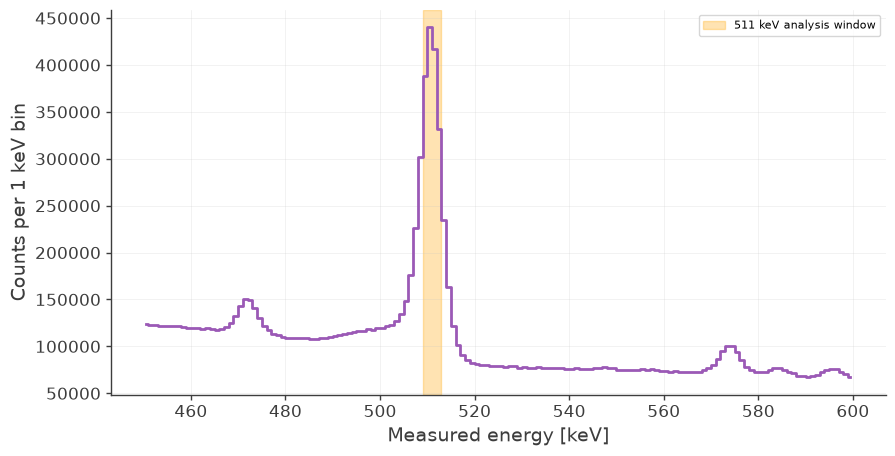

In [24]:
# Plot the combined energy spectrum
plt.figure(figsize=(10, 5))
plt.step(
    energy_bin_centers,
    energy_counts_all,
    where="mid",
)

# Highlight the 511 keV analysis window
plt.axvspan(
    509,
    513,
    color="orange",
    alpha=0.3,
    label="511 keV analysis window",
)

plt.xlabel("Measured energy [keV]")
plt.ylabel("Counts per 1 keV bin")
plt.legend()
plt.grid(alpha=0.3)


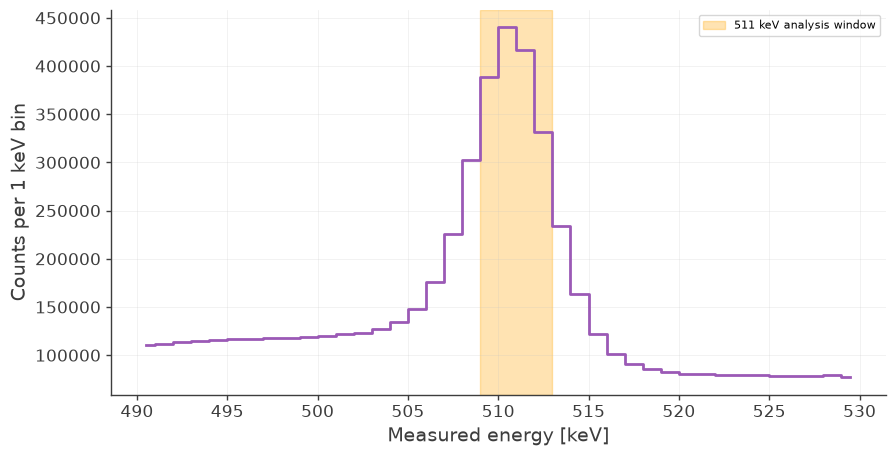

In [25]:
# Select the region around the 511 keV feature
zoom_mask = (
    (energy_bin_centers >= 490)
    & (energy_bin_centers <= 530)
)

# Plot a closer view of the 511 keV feature
plt.figure(figsize=(10, 5))
plt.step(
    energy_bin_centers[zoom_mask],
    energy_counts_all[zoom_mask],
    where="mid",
)

# Highlight the final 511 keV analysis window
plt.axvspan(
    509,
    513,
    color="orange",
    alpha=0.3,
    label="511 keV analysis window",
)

plt.xlabel("Measured energy [keV]")
plt.ylabel("Counts per 1 keV bin")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The broad 450–600 keV interval is used only to inspect the local spectrum and identify nearby structures. The auxiliary product below is restricted to 480–540 keV with 1 keV bins, providing the energy resolution needed by `LineBackgroundEstimation`.


#### 2. Create the fine-energy auxiliary product


In [26]:
# define the fine energy bins for the background-estimation product 
background_energy_bin_edges = np.arange(
    480,
    541,
    1,
    dtype=float,
)

In [27]:
# checking the auxiliarity energy binning
print('Number of bins:', len(background_energy_bin_edges) - 1)
print('Energy range', background_energy_bin_edges[[0,-1]])

Number of bins: 60
Energy range [480. 540.]


In [28]:
config_511_background_path = write_custom_binning_yaml(
    base_yaml_path=paths.config_511_path,
    output_yaml_path=(
        paths.config_dir / "dataio_511_background.yaml"
    ),
    energy_bins= background_energy_bin_edges
)

In [29]:
# Create and load the auxiliary background products for all weeks
background_analysis = {}

for week, input_path in paths.weekly_paths.items():
    output_prefix = (
        paths.data_dir_out
        / f"dc4_week_{week}_511_background_binned"
    )
    output_path = output_prefix.with_suffix(".hdf5")

    # Create the weekly BinnedData object
    background_analysis[week] = cp.BinnedData(
        config_511_background_path
    )

    # Bin the weekly events only if the output is missing
    if not output_path.exists():
        background_analysis[week].get_binned_data(
            unbinned_data=str(input_path),
            output_name=str(output_prefix),
        )

    # Always load the existing or newly created histogram
    background_analysis[week].load_binned_data_from_hdf5(
        binned_data=str(output_path)
    )
    background_analysis[week].get_binning_info()

In [30]:
# Project week 1 while preserving Em, Phi and PsiChi
background_hist_all = (
    background_analysis[1]
    .binned_data
    .project("Em", "Phi", "PsiChi")
)

# Add the remaining week histograms
for week in range(2, 15):
    week_hist = (
        background_analysis[week]
        .binned_data
        .project("Em", "Phi", "PsiChi")
    )

    background_hist_all = background_hist_all + week_hist

In [31]:
# Validate the combined histogram
print("Shape:", background_hist_all.shape)
print("Axes:", background_hist_all.axes.labels)
print("Sparse:", background_hist_all.is_sparse)

Shape: (60, 60, 3072)
Axes: ['Em' 'Phi' 'PsiChi']
Sparse: True


`background_hist_all` contains the 14-week observation projected onto `Em`, `Phi`, and `PsiChi`. It still contains both source and background events; the name indicates its role as input to the background estimator, not that it is already a pure-background histogram.


#### 3. Initialize the line-background estimator


In [32]:
# Initialise the 511 keV line-background estimator!
line_background_estimator = cp.LineBackgroundEstimation(background_hist_all)

#### 4. Fit the tutorial spectral model

The COSIpy tutorial models a smooth power-law continuum plus Gaussian instrumental-line components. Its Al-26 example uses several Gaussians. For the local 480–540 keV interval, the same tutorial structure is tested with one Gaussian component around the dominant line-like feature.

The final science window is 509–513 keV, but the broader reconstructed feature is excluded from the spectral fit so that the model is constrained by the surrounding spectrum.


In [33]:
def powerlaw(energy, normalization, index, pivot):
    """Evaluate a power-law continuum."""
    return normalization * (energy / pivot) ** index


def gaussian(energy, area, center, sigma):
    """Evaluate a Gaussian line with integrated normalization."""
    return (
        area
        / (sigma * np.sqrt(2.0 * np.pi))
        * np.exp(
            -0.5 * ((energy - center) / sigma) ** 2
        )
    )

(<Axes: xlabel='Em [keV]'>, <Quantity 518. keV>)

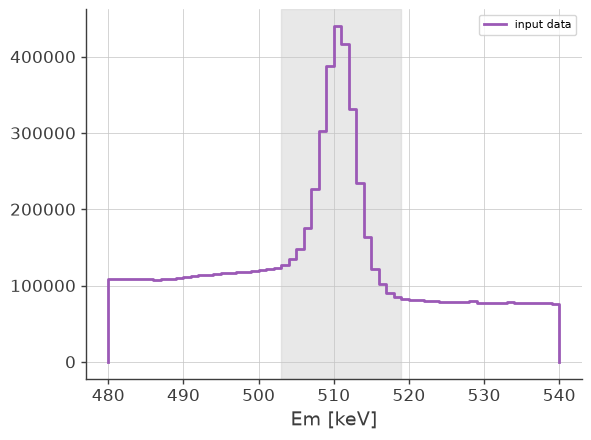

In [34]:
# Exclude the full reconstructed line feature from the continuum fit.
fit_exclusion_range = np.array([503.5, 518.5]) * u.keV

line_background_estimator.set_mask(
    fit_exclusion_range
)

line_background_estimator.plot_energy_spectrum()

In [35]:
def bkg_model_with_line(
    energy,
    continuum_normalization,
    continuum_index,
    line_area,
    line_center,
    line_sigma,
):
    """Model the continuum plus one instrumental line component."""

    continuum = powerlaw(
        energy,
        continuum_normalization,
        continuum_index,
        pivot=511.0,
    )

    instrumental_line = gaussian(
        energy,
        line_area,
        line_center,
        line_sigma,
    )

    return continuum + instrumental_line

In [ ]:
# Initial guesses for the continuum and instrumental-line components.
initial_line_model_parameters = [
    9.4e4,   # Continuum normalization near 511 keV
    -4.2,    # Continuum power-law index
    2.6e6,   # Integrated counts in the Gaussian component
    511.0,   # Gaussian center in keV
    3.0,     # Gaussian sigma in keV
]

line_background_estimator.set_bkg_energy_spectrum_model(
    bkg_model_with_line,
    initial_line_model_parameters,
)

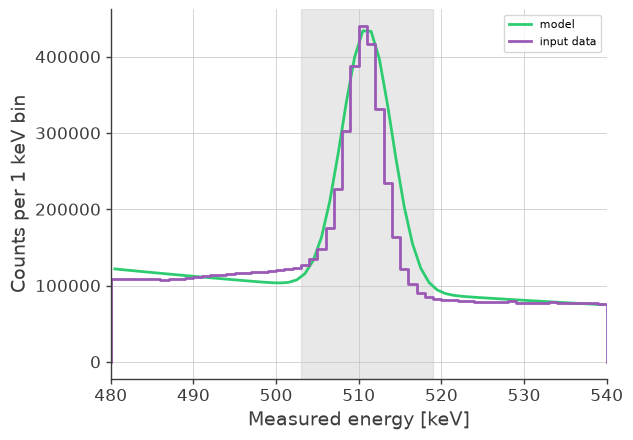

In [37]:
# Inspect the initial composite model before fitting.
ax, _ = line_background_estimator.plot_energy_spectrum()

ax.set_xlim(480, 540)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")

plt.show()

In [38]:
# Constrain only parameters that have physical restrictions.
line_parameter_limits = {
    0: (0.0, None),     # Continuum normalization must be positive
    2: (0.0, None),     # Gaussian area must be positive
    3: (509.0, 513.0),  # Line center must remain around 511 keV
    4: (0.1, None),     # Gaussian width must be positive and non-zero
}

line_model_fit = line_background_estimator.fit_energy_spectrum(
    param_limits=line_parameter_limits
)

line_model_fit

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -4.462e+07                 │              Nfcn = 473              │
│ EDM = 1.66e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │ 90.6600e3 │ 0.0014e3  │            │            │    0    │         │       │
│ 1 │ x1   │  -4.150   │   0.013   │            │            │         │         │       │
│ 2 │ x2   │743.9867e3 │ 0.0014e3  │            │            │    0    │         │       │
│ 3 │ x3   │ 509.00000 │  0.00022  │            │            │   509   │   513   │       │
│ 4 │ x4   │   5.954   │   0.028   │            │            │   0.1   │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬────────────────────────────────────────────────────────┐
│    │         x0         x1         x2         x3         x4 │
├────┼────────────────────────────────────────────────────────┤
│ x0 │          2    0.08e-3          0  25.16e-12    -0.8e-3 │
│ x1 │    0.08e-3   0.000158          0 -10.19e-12    0.05e-3 │
│ x2 │          0          0          2   0.10e-12         -0 │
│ x3 │  25.16e-12 -10.19e-12   0.10e-12   1.28e-13  -6.75e-12 │
│ x4 │    -0.8e-3    0.05e-3         -0  -6.75e-12     0.0008 │
└────┴────────────────────────────────────────────────────────┘

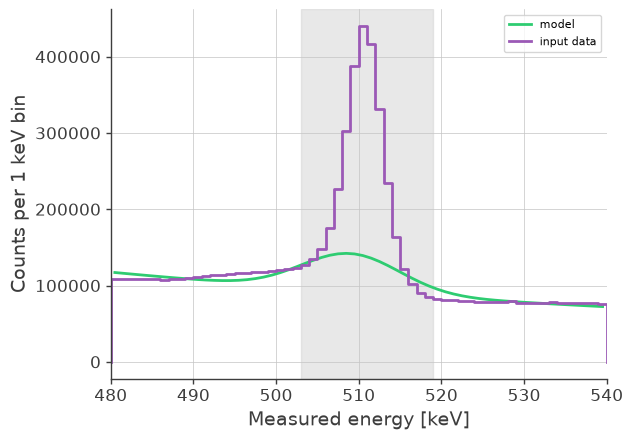

In [39]:
# Plot the fitted continuum-plus-line model over the observed spectrum.
ax, _ = line_background_estimator.plot_energy_spectrum()

ax.set_xlim(480, 540)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")

plt.show()


The current fit reaches a numerical minimum, but the Gaussian center reaches its lower allowed limit. This indicates that the symmetric one-Gaussian description is not yet a validated physical model for the 511 keV background. It is nevertheless retained as the tutorial-based candidate that will be tested against the simulated background.


#### 5. Define the source window and background sidebands


In [40]:
# Final science window for the 511 keV analysis.
source_energy_range = np.array([509.0, 513.0]) * u.keV

# Sidebands used to estimate the background distribution in Compton data space.
background_region_low = np.array([480.0, 503.0]) * u.keV
background_region_high = np.array([519.0, 540.0]) * u.keV

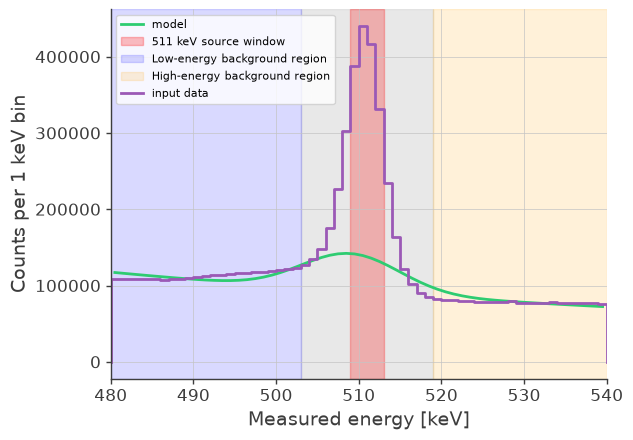

In [41]:
# Visualize the source window and the sidebands used for background estimation.
ax, _ = line_background_estimator.plot_energy_spectrum()

ax.axvspan(
    source_energy_range[0].value,
    source_energy_range[1].value,
    color="red",
    alpha=0.25,
    label="511 keV source window",
)

ax.axvspan(
    background_region_low[0].value,
    background_region_low[1].value,
    color="blue",
    alpha=0.15,
    label="Low-energy background region",
)

ax.axvspan(
    background_region_high[0].value,
    background_region_high[1].value,
    color="orange",
    alpha=0.15,
    label="High-energy background region",
)

ax.set_xlim(480, 540)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")
ax.legend()

plt.show()

The two sidebands provide the observed spatial distribution in Compton data space. The fitted spectral model supplies the normalization factor that transfers the sideband counts into the 509–513 keV source window.


#### 6. Generate the tutorial background variants


The tutorial generates five versions of the same background estimate:

- `raw`: the unfiltered sideband template.
- `smoothing`: Gaussian angular smoothing with a 20 degree FWHM.
- `l_cut`: harmonic filtering that retains multipoles through `l = 4`.
- `rebin+smoothing`: temporary grouping of 10 `Phi` bins before smoothing.
- `rebin+l_cut`: temporary grouping of 10 `Phi` bins before harmonic filtering.

These are not five different spectral fits. They share the fitted spectral normalization and differ in how the spatial template is filtered. Following the tutorial, their `Phi` and `PsiChi` distributions will be plotted against the simulated background in the validation section.


In [42]:
# Build the raw data-driven background model in the 509–513 keV window.
background_model_511_raw = (
    line_background_estimator.generate_bkg_model_histogram(
        source_energy_range=source_energy_range,
        bkg_estimation_energy_ranges=[
            background_region_low,
            background_region_high,
        ],
    )
)

In [43]:
# Generate the smoothed background model following the tutorial.
background_model_511_smoothing = (
    line_background_estimator.generate_bkg_model_histogram(
        source_energy_range=source_energy_range,
        bkg_estimation_energy_ranges=[
            background_region_low,
            background_region_high,
        ],
        smoothing_fwhm=20 * u.deg,
    )
)

In [44]:
# Generate the harmonic-filtered background model.
background_model_511_l_cut = (
    line_background_estimator.generate_bkg_model_histogram(
        source_energy_range=source_energy_range,
        bkg_estimation_energy_ranges=[
            background_region_low,
            background_region_high,
        ],
        l_cut=4,
    )
)

In [45]:
# Rebin Phi before applying the angular smoothing.
background_model_511_rebin_smoothing = (
    line_background_estimator.generate_bkg_model_histogram(
        source_energy_range=source_energy_range,
        bkg_estimation_energy_ranges=[
            background_region_low,
            background_region_high,
        ],
        smoothing_fwhm=20 * u.deg,
        rebin_phi=10,
    )
)

In [46]:
# Rebin Phi before applying the harmonic-space filter.
background_model_511_rebin_l_cut = (
    line_background_estimator.generate_bkg_model_histogram(
        source_energy_range=source_energy_range,
        bkg_estimation_energy_ranges=[
            background_region_low,
            background_region_high,
        ],
        l_cut=4,
        rebin_phi=10,
    )
)

In [47]:
# Collect all background models for comparison.
background_models_511 = {
    "raw": background_model_511_raw,
    "smoothing": background_model_511_smoothing,
    "l_cut": background_model_511_l_cut,
    "rebin+smoothing": background_model_511_rebin_smoothing,
    "rebin+l_cut": background_model_511_rebin_l_cut,
}

In [55]:
# Verify the final energy binning of every generated model.
for name, model in background_models_511.items():
    print(
        name,
        "shape:",
        model.shape,
        "energy edges:",
        model.axes["Em"].edges,
    )

raw shape: (1, 60, 3072) energy edges: [509. 513.] keV
smoothing shape: (1, 60, 3072) energy edges: [509. 513.] keV
l_cut shape: (1, 60, 3072) energy edges: [509. 513.] keV
rebin+smoothing shape: (1, 60, 3072) energy edges: [509. 513.] keV
rebin+l_cut shape: (1, 60, 3072) energy edges: [509. 513.] keV


#### 7. Save the tutorial background models


In [48]:
# Save all generated 511 keV background models.
background_model_511_raw.write(
    str(paths.data_dir_out / "background_model_511_raw.hdf5"),
    overwrite=True,
)

background_model_511_smoothing.write(
    str(paths.data_dir_out / "background_model_511_smoothing.hdf5"),
    overwrite=True,
)

background_model_511_l_cut.write(
    str(paths.data_dir_out / "background_model_511_l_cut.hdf5"),
    overwrite=True,
)

background_model_511_rebin_smoothing.write(
    str(
        paths.data_dir_out
        / "background_model_511_rebin_smoothing.hdf5"
    ),
    overwrite=True,
)

background_model_511_rebin_l_cut.write(
    str(
        paths.data_dir_out
        / "background_model_511_rebin_l_cut.hdf5"
    ),
    overwrite=True,
)

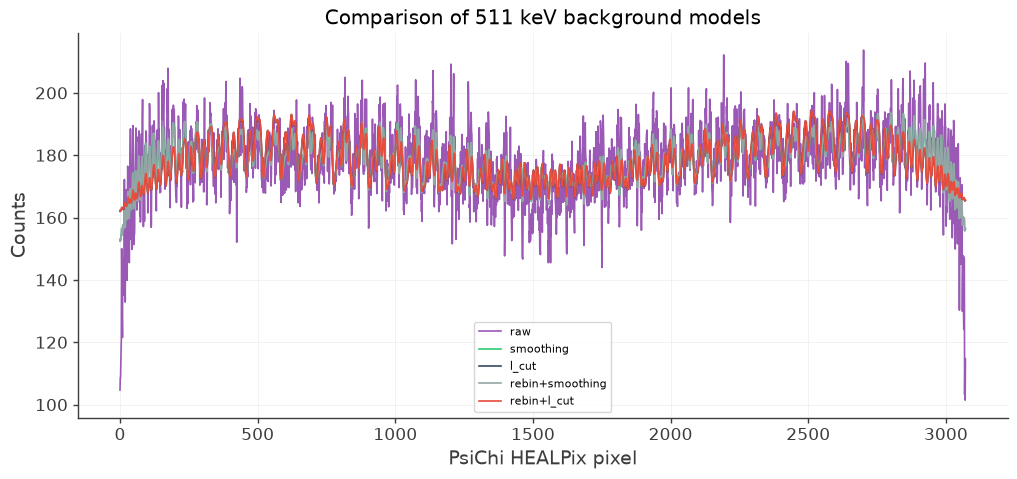

In [52]:
# Compare all generated background models in one PsiChi projection.
fig, ax = plt.subplots(figsize=(12, 5))

for name, model in background_models_511.items():
    psichi_projection = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    values = np.asarray(psichi_projection.contents)
    pixels = np.arange(values.size)

    ax.plot(
        pixels,
        values,
        label=name,
        linewidth=1.2,
    )

ax.set_xlabel("PsiChi HEALPix pixel")
ax.set_ylabel("Counts")
ax.set_title("Comparison of 511 keV background models")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

### Validation with simulated total background

The next tutorial stage is intentionally left incomplete. It will:

1. Bin and load the provided simulated total background in the 509–513 keV window.
2. Compare its normalization with all five estimated models.
3. Compare the `Phi` distributions and residuals.
4. Compare the `PsiChi` distributions and residuals.

No model should be selected for the imaging analysis until these comparisons are complete.


In [54]:
# Download the simulated DC4 total background used for validation.
simulated_background_filename = (
    "Total_DC4_BG_3months_unbinned_data_"
    "filtered_with_SAAcut_withSAAbck.fits.gz"
)

simulated_background_remote_path = (
    "COSI-SMEX/DC4/Data/Backgrounds/"
    + simulated_background_filename
)

simulated_background_path = (
    paths.data_dir / simulated_background_filename
)

if not simulated_background_path.exists():
    fetch_wasabi_file(
        simulated_background_remote_path,
        output=simulated_background_path,
    )
else:
    print(
        "Background file already exists:",
        simulated_background_path,
    )

In [56]:
# Define the output product for the simulated 511 keV background.
simulated_background_prefix = (
    paths.data_dir_out
    / "simulated_total_background_511_binned"
)
simulated_background_binned_path = (
    simulated_background_prefix.with_suffix(".hdf5")
)

# Create the BinnedData object using the final 509–513 keV binning.
simulated_background_analysis = cp.BinnedData(
    paths.config_511_path
)

# Bin the simulated background only if the output is missing.
if not simulated_background_binned_path.exists():
    simulated_background_analysis.get_binned_data(
        unbinned_data=str(simulated_background_path),
        output_name=str(simulated_background_prefix),
    )

# Load the existing or newly generated histogram.
simulated_background_analysis.load_binned_data_from_hdf5(
    binned_data=str(simulated_background_binned_path)
)
simulated_background_analysis.get_binning_info()

# Sum over time while preserving Em, Phi and PsiChi.
simulated_background_511 = (
    simulated_background_analysis
    .binned_data
    .project("Em", "Phi", "PsiChi")
)

# Verify compatibility with the estimated background models.
print("Shape:", simulated_background_511.shape)
print("Axes:", simulated_background_511.axes.labels)
print(
    "Energy edges:",
    simulated_background_511.axes["Em"].edges,
)

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


Shape: (1, 60, 3072)
Axes: ['Em' 'Phi' 'PsiChi']
Energy edges: [509. 513.] keV


In [57]:
# Convert the simulated background to dense form for count comparison.
simulated_background_511_dense = (
    simulated_background_511.to_dense(copy=False)
)

simulated_background_counts = float(
    np.sum(simulated_background_511_dense.contents)
)

print(
    f"Simulated background: "
    f"{simulated_background_counts:.1f}"
)

# Compare every data-driven model with the simulated background.
for name, model in background_models_511.items():
    model_counts = float(
        np.sum(model.to_dense(copy=False).contents)
    )

    difference = (
        simulated_background_counts / model_counts - 1.0
    ) * 100.0

    print(
        f"{name:20s}: "
        f"{model_counts:.1f}  "
        f"diff = {difference:+.2f}%"
    )

Simulated background: 1374985.0
raw                 : 548027.1  diff = +150.90%
smoothing           : 547985.0  diff = +150.92%
l_cut               : 547662.6  diff = +151.06%
rebin+smoothing     : 548027.1  diff = +150.90%
rebin+l_cut         : 548027.1  diff = +150.90%



WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide



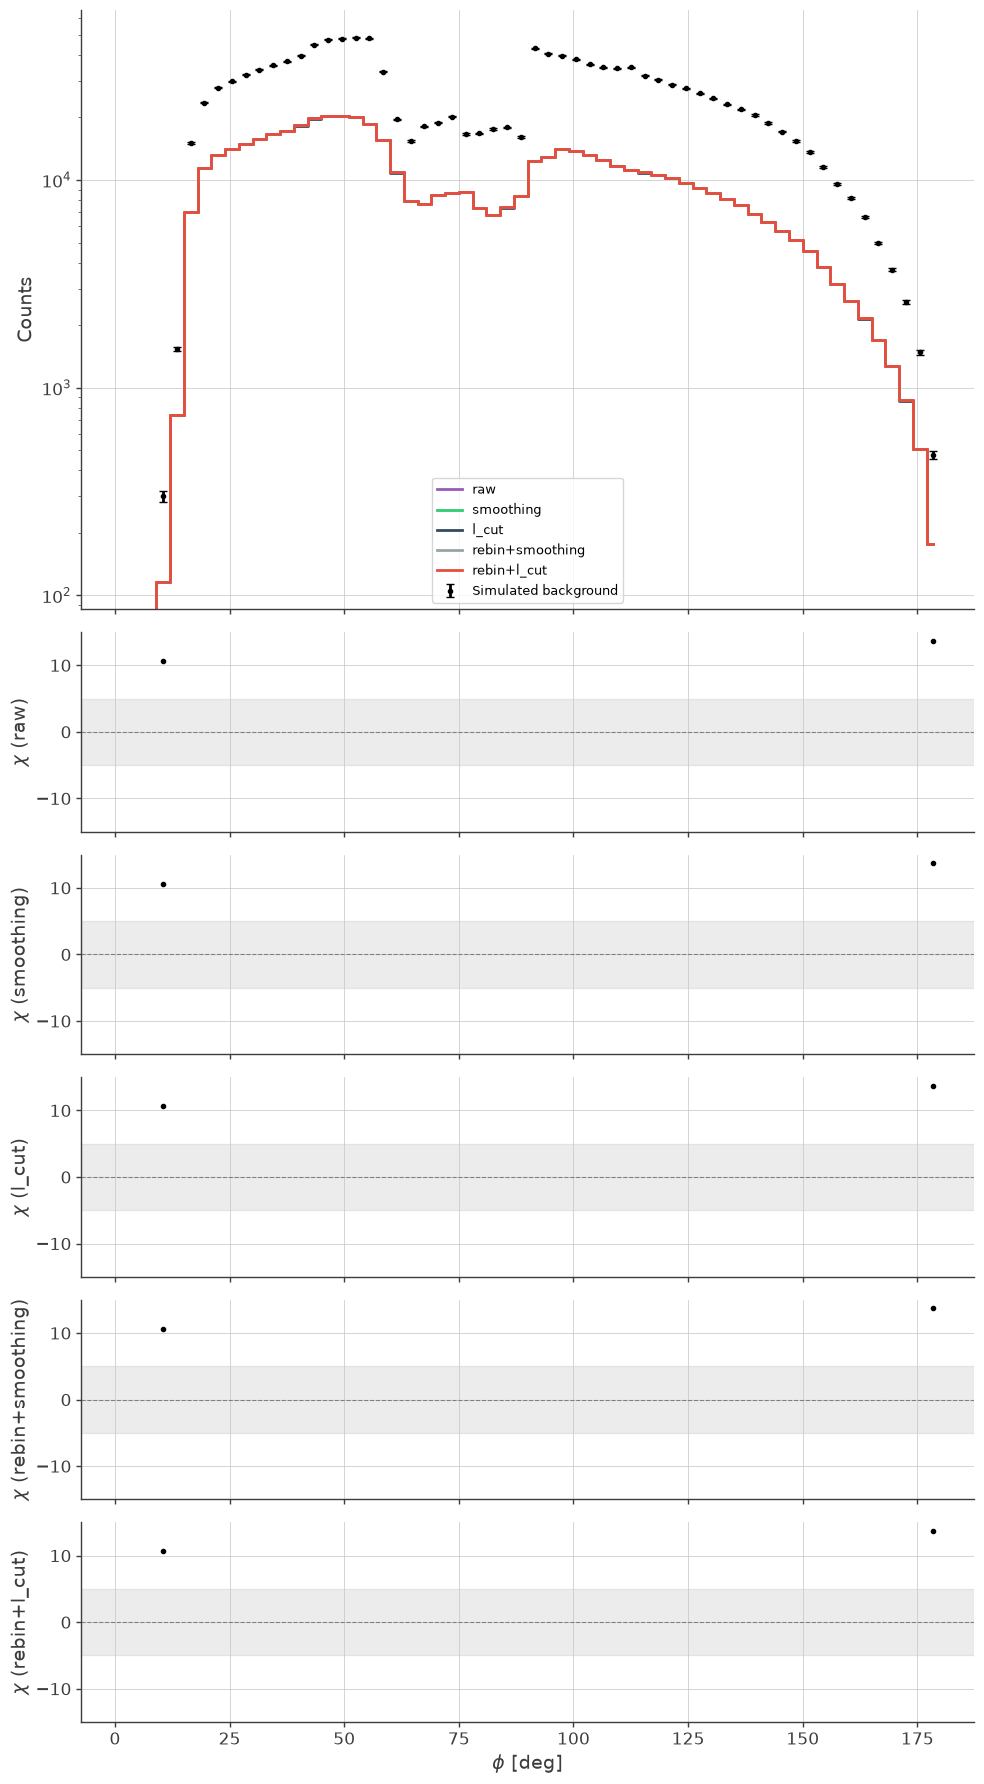

In [58]:
# Project the simulated background onto Phi.
phi_simulated = (
    simulated_background_511
    .project("Phi")
    .to_dense(copy=False)
)

phi_centers = phi_simulated.axis.centers

fig, axes = plt.subplots(
    len(background_models_511) + 1,
    1,
    figsize=(10, 18),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3]
        + [1] * len(background_models_511)
    },
)

# Plot the simulated background and every estimated model.
axes[0].errorbar(
    phi_centers,
    phi_simulated.contents,
    yerr=np.sqrt(phi_simulated.contents),
    fmt=".",
    color="black",
    label="Simulated background",
    capsize=3,
)

for name, model in background_models_511.items():
    phi_model = (
        model
        .project("Phi")
        .to_dense(copy=False)
    )

    axes[0].step(
        phi_centers,
        phi_model.contents,
        where="mid",
        label=name,
    )

axes[0].set_ylabel("Counts")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid()

# Plot standardized residuals for each model.
for ax, (name, model) in zip(
    axes[1:],
    background_models_511.items(),
):
    phi_model = (
        model
        .project("Phi")
        .to_dense(copy=False)
    )

    residual = (
        phi_simulated.contents
        - phi_model.contents
    ) / np.sqrt(phi_simulated.contents)

    ax.plot(
        phi_centers,
        residual,
        ".",
        color="black",
    )
    ax.axhline(
        0,
        color="grey",
        linestyle="--",
        linewidth=0.8,
    )
    ax.axhspan(
        -5,
        5,
        color="grey",
        alpha=0.15,
    )
    ax.set_ylabel(fr"$\chi$ ({name})")
    ax.set_ylim(-15, 15)
    ax.grid()

axes[-1].set_xlabel(r"$\phi$ [deg]")

plt.tight_layout()
plt.show()

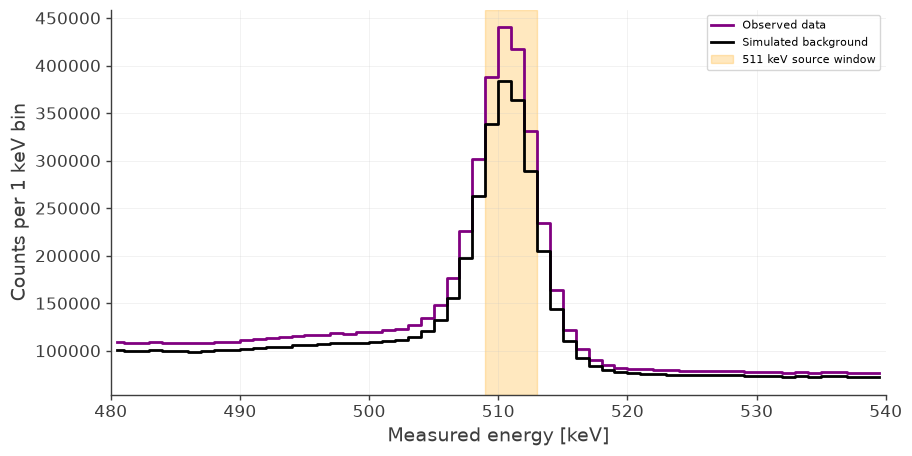

In [59]:
# Build the fine-energy spectrum of the simulated background.
with fits.open(
    simulated_background_path,
    memmap=True,
) as hdul:
    simulated_background_energy_counts, _ = np.histogram(
        hdul[1].data["Energies"],
        bins=background_energy_bin_edges,
    )

# Obtain the measured spectrum containing sources plus background.
observed_energy_spectrum = (
    background_hist_all
    .project("Em")
    .to_dense(copy=False)
)

energy_centers = 0.5 * (
    background_energy_bin_edges[:-1]
    + background_energy_bin_edges[1:]
)

# Compare the measured spectrum with the simulated background.
fig, ax = plt.subplots(figsize=(10, 5))

ax.step(
    energy_centers,
    observed_energy_spectrum.contents,
    where="mid",
    label="Observed data",
    color="purple",
)

ax.step(
    energy_centers,
    simulated_background_energy_counts,
    where="mid",
    label="Simulated background",
    color="black",
)

ax.axvspan(
    509,
    513,
    color="orange",
    alpha=0.25,
    label="511 keV source window",
)

ax.set_xlim(480, 540)
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts per 1 keV bin")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

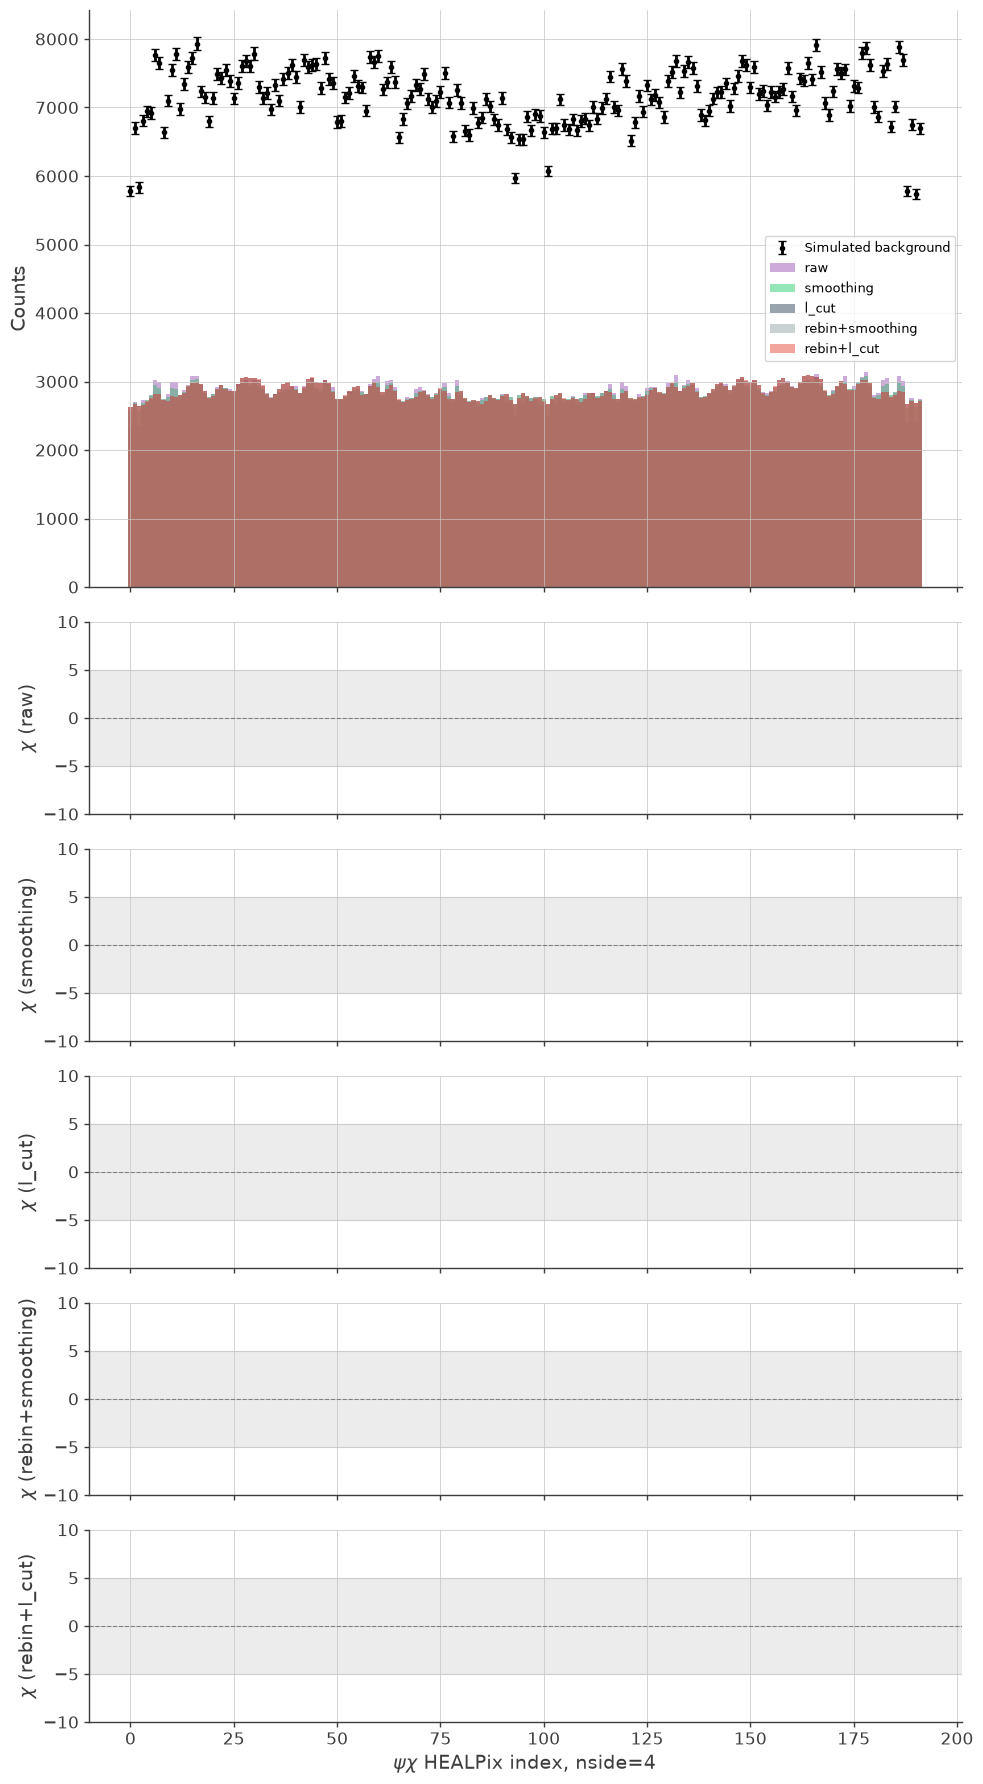

In [61]:
# Degrade the PsiChi distributions to nside=4 for comparison.
nside_out = 4

psichi_simulated = (
    simulated_background_511
    .project("PsiChi")
    .to_dense(copy=False)
)

psichi_simulated_rebinned = hp.ud_grade(
    psichi_simulated[:],
    nside_out,
    power=-2,
)

pixels = np.arange(
    hp.nside2npix(nside_out)
)

fig, axes = plt.subplots(
    len(background_models_511) + 1,
    1,
    figsize=(10, 18),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3]
        + [1] * len(background_models_511)
    },
)

# Compare the simulated background with all estimated models.
axes[0].errorbar(
    pixels,
    psichi_simulated_rebinned,
    yerr=np.sqrt(psichi_simulated_rebinned),
    fmt=".",
    color="black",
    label="Simulated background",
    capsize=3,
)

for name, model in background_models_511.items():
    psichi_model = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    psichi_model_rebinned = hp.ud_grade(
        psichi_model[:],
        nside_out,
        power=-2,
    )

    axes[0].bar(
        pixels,
        psichi_model_rebinned,
        width=1,
        alpha=0.5,
        label=name,
    )

axes[0].set_ylabel("Counts")
axes[0].legend(fontsize=9)
axes[0].grid()

# Plot standardized residuals.
for ax, (name, model) in zip(
    axes[1:],
    background_models_511.items(),
):
    psichi_model = (
        model
        .project("PsiChi")
        .to_dense(copy=False)
    )

    psichi_model_rebinned = hp.ud_grade(
        psichi_model[:],
        nside_out,
        power=-2,
    )

    residual = (
        psichi_simulated_rebinned
        - psichi_model_rebinned
    ) / np.sqrt(psichi_simulated_rebinned)

    ax.plot(
        pixels,
        residual,
        ".",
        color="black",
    )
    ax.axhline(
        0,
        color="grey",
        linestyle="--",
        linewidth=0.8,
    )
    ax.axhspan(
        -5,
        5,
        color="grey",
        alpha=0.15,
    )
    ax.set_ylabel(fr"$\chi$ ({name})")
    ax.set_ylim(-10, 10)
    ax.grid()

axes[-1].set_xlabel(
    rf"$\psi\chi$ HEALPix index, nside={nside_out}"
)

plt.tight_layout()
plt.show()

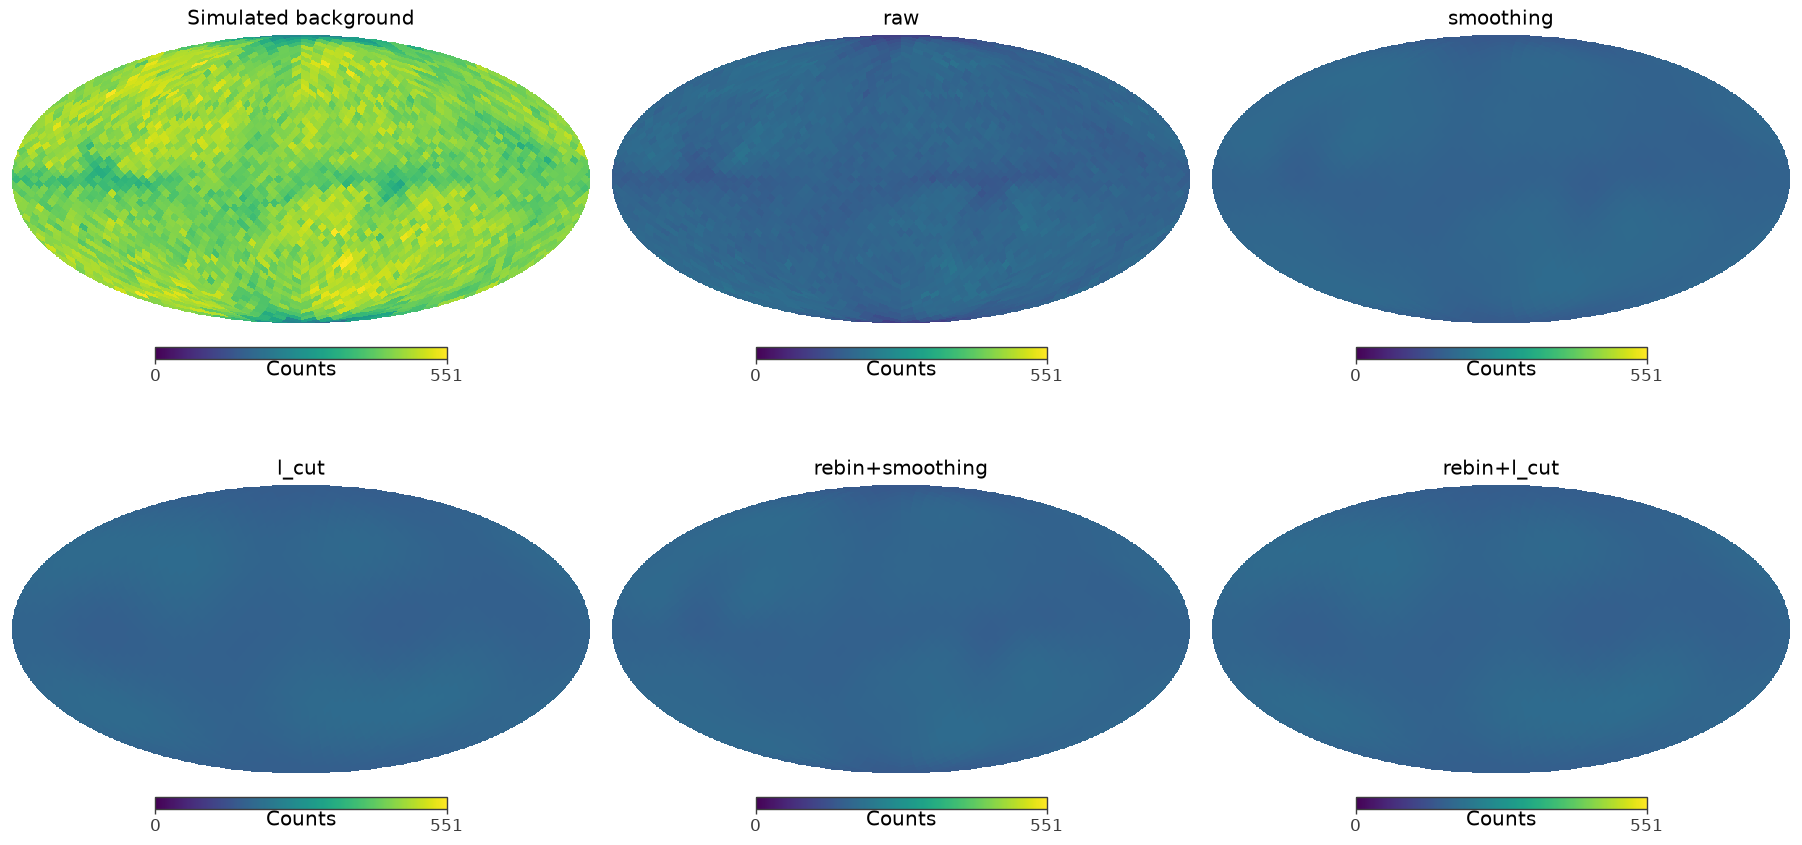

In [62]:
# Collect the simulated background and estimated PsiChi maps.
psichi_maps = {
    "Simulated background": np.asarray(
        simulated_background_511
        .project("PsiChi")
        .to_dense(copy=False)
        .contents
    )
}

for name, model in background_models_511.items():
    psichi_maps[name] = np.asarray(
        model
        .project("PsiChi")
        .to_dense(copy=False)
        .contents
    )

# Use one common color scale for a direct normalization comparison.
common_min = 0.0
common_max = psichi_maps["Simulated background"].max()

fig = plt.figure(figsize=(18, 9))

for panel, (name, values) in enumerate(
    psichi_maps.items(),
    start=1,
):
    hp.mollview(
        values,
        fig=fig.number,
        sub=(2, 3, panel),
        title=name,
        unit="Counts",
        min=common_min,
        max=common_max,
    )

plt.show()

***
## Fit Galactic disk and bulge model

In [50]:
# Using extended_response
# Select Ei=0 and Em=0
response_511 = extended_response[:, 0, 0, :, :]

In [51]:

print("511 keV response:", response_511.shape)
print("511 keV (reduced) response:", response_511.shape[1:])
print("Total observed shape:" , observed_counts_all.shape)

511 keV response: (3072, 60, 3072)
511 keV (reduced) response: (60, 3072)
Total observed shape: (60, 3072)
